# PROJECT #4 -- Comparing National Risk Index Scores and a Custom Risk Model for Wyoming and Montana

#### By: Camdin McGuigan, Nay Law Htoo, and Ahmad Rezaie

### Import Packages

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

### Load the Data Files

In [50]:
WY_nri = pd.read_csv("NRI_Table_CensusTracts_Wyoming(in).csv")
MT_nri = pd.read_csv("NRI_Table_CensusTracts_Montana.csv")

WY_svi = pd.read_csv("Wyoming.csv")
MT_svi = pd.read_csv("Montana.csv")

nri_dictionary = pd.read_csv("NRIDataDictionary.csv")

tracts = gpd.read_file("NRI_Shapefile_CensusTracts.shp")

### Check That the Files Loaded Correctly

In [52]:
print(WY_nri.head())
print()
print(MT_nri.head())
print()
print(WY_svi.head())
print()
print(MT_svi.head())
print()
print(tracts.head())

    OID_        NRI_ID    STATE STATEABBRV  STATEFIPS  COUNTY COUNTYTYPE  \
0  83934  T56001962700  Wyoming         WY         56  Albany     County   
1  83935  T56001962800  Wyoming         WY         56  Albany     County   
2  83936  T56001962900  Wyoming         WY         56  Albany     County   
3  83937  T56001963000  Wyoming         WY         56  Albany     County   
4  83938  T56001963101  Wyoming         WY         56  Albany     County   

   COUNTYFIPS  STCOFIPS   TRACT  ...  WNTW_EALS            WNTW_EALR  \
0           1     56001  962700  ...  92.677972      Relatively High   
1           1     56001  962800  ...  91.011579      Relatively High   
2           1     56001  962900  ...  83.400662  Relatively Moderate   
3           1     56001  963000  ...  88.255396      Relatively High   
4           1     56001  963101  ...  92.484205      Relatively High   

      WNTW_ALRB     WNTW_ALRP     WNTW_ALRA  WNTW_ALR_NPCTL    WNTW_RISKV  \
0  1.074730e-06  4.000220e-07  7.

### Check Column Names

In [53]:
print("Wyoming NRI Columns")
print(WY_nri.columns)
print()

print("Montana NRI Columns")
print(MT_nri.columns)
print()

print("Wyoming SVI Columns")
print(WY_svi.columns)
print()

print("Montana SVI Columns")
print(MT_svi.columns)
print()

print("Shapefile Columns")
print(tracts.columns)

Wyoming NRI Columns
Index(['OID_', 'NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS', 'COUNTY',
       'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS', 'TRACT',
       ...
       'WNTW_EALS', 'WNTW_EALR', 'WNTW_ALRB', 'WNTW_ALRP', 'WNTW_ALRA',
       'WNTW_ALR_NPCTL', 'WNTW_RISKV', 'WNTW_RISKS', 'WNTW_RISKR', 'NRI_VER'],
      dtype='object', length=467)

Montana NRI Columns
Index(['OID_', 'NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS', 'COUNTY',
       'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS', 'TRACT',
       ...
       'WNTW_EALS', 'WNTW_EALR', 'WNTW_ALRB', 'WNTW_ALRP', 'WNTW_ALRA',
       'WNTW_ALR_NPCTL', 'WNTW_RISKV', 'WNTW_RISKS', 'WNTW_RISKR', 'NRI_VER'],
      dtype='object', length=467)

Wyoming SVI Columns
Index(['ST', 'STATE', 'ST_ABBR', 'STCNTY', 'COUNTY', 'FIPS', 'LOCATION',
       'AREA_SQMI', 'E_TOTPOP', 'M_TOTPOP',
       ...
       'EP_ASIAN', 'MP_ASIAN', 'EP_AIAN', 'MP_AIAN', 'EP_NHPI', 'MP_NHPI',
       'EP_TWOMORE', 'MP_TWOMORE', 'EP_OTHERRACE', 'MP_OTHERRACE'],
      dtype='object',

### Create a Matching Census Tract ID

In [61]:
WY_nri["TRACTFIPS"] = WY_nri["STCOFIPS"].astype(str).str.replace(".0", "", regex=False).str.strip().str.zfill(11)
MT_nri["TRACTFIPS"] = MT_nri["STCOFIPS"].astype(str).str.replace(".0", "", regex=False).str.strip().str.zfill(11)

WY_svi["TRACTFIPS"] = WY_svi["FIPS"].astype(str).str.replace(".0", "", regex=False).str.strip().str.zfill(11)
MT_svi["TRACTFIPS"] = MT_svi["FIPS"].astype(str).str.replace(".0", "", regex=False).str.strip().str.zfill(11)

tracts["TRACTFIPS"] = tracts["TRACTFIPS"].astype(str).str.replace(".0", "", regex=False).str.strip().str.zfill(11)

### Merge NRI and SVI Data

In [62]:
WY_data = pd.merge(WY_nri, WY_svi, on="TRACTFIPS", how="left")
MT_data = pd.merge(MT_nri, MT_svi, on="TRACTFIPS", how="left")

### Combine Both States into One Dataset

In [63]:
WY_data["STATE_NAME"] = "Wyoming"
MT_data["STATE_NAME"] = "Montana"

combined_data = pd.concat([WY_data, MT_data], ignore_index=True)

### Fill Missing Values

In [64]:
combined_data["RISK_SCORE"] = combined_data["RISK_SCORE"].fillna(0)
combined_data["EAL_SCORE"] = combined_data["EAL_SCORE"].fillna(0)
combined_data["SOVI_SCORE"] = combined_data["SOVI_SCORE"].fillna(0)
combined_data["RESL_SCORE"] = combined_data["RESL_SCORE"].fillna(0)
combined_data["WFIR_RISKS"] = combined_data["WFIR_RISKS"].fillna(0)

### Clean Shapefile for Mapping

In [65]:
tracts_clean = tracts[
    tracts.geometry.notna() &
    (~tracts.geometry.is_empty) &
    (tracts["RISK_SCORE"].notna())
].copy()

### Map Data by State

In [66]:
wyoming_map = tracts_clean[tracts_clean["STATE"].str.lower() == "wyoming"].copy()
montana_map = tracts_clean[tracts_clean["STATE"].str.lower() == "montana"].copy()

### Map of Wyoming NRI Risk Score

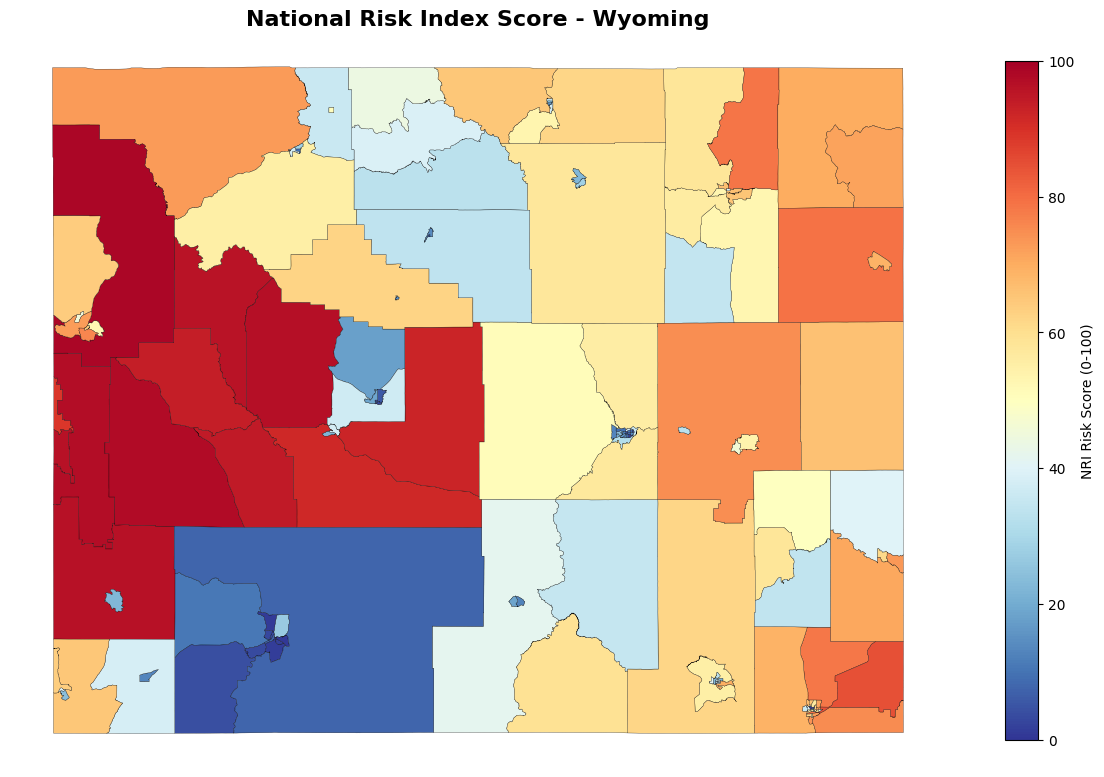

In [67]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

wyoming_map.plot(
    column="RISK_SCORE",
    ax=ax,
    legend=True,
    linewidth=0.2,
    edgecolor="black",
    cmap="RdYlBu_r",
    vmin=0,
    vmax=100,
    legend_kwds={"label": "NRI Risk Score (0-100)", "shrink": 0.7},
    missing_kwds={"color": "lightgrey", "label": "No Data"}
)

ax.set_title("National Risk Index Score - Wyoming", fontsize=16, fontweight="bold")
ax.set_axis_off()

plt.tight_layout()
plt.show()

### Montana NRI Risk Map

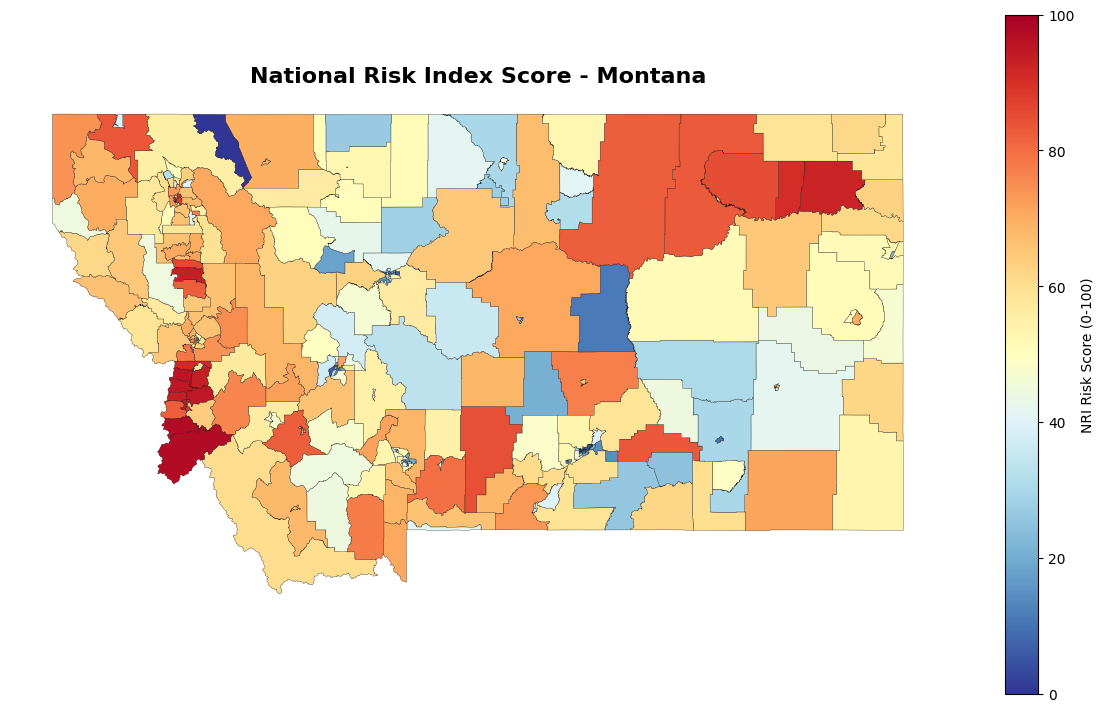

In [68]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

montana_map.plot(
    column="RISK_SCORE",
    ax=ax,
    legend=True,
    linewidth=0.2,
    edgecolor="black",
    cmap="RdYlBu_r",
    vmin=0,
    vmax=100,
    legend_kwds={"label": "NRI Risk Score (0-100)", "shrink": 0.7},
    missing_kwds={"color": "lightgrey", "label": "No Data"}
)

ax.set_title("National Risk Index Score - Montana", fontsize=16, fontweight="bold")
ax.set_axis_off()

plt.tight_layout()
plt.show()

### Add Custom Risk Score to Shapefile

In [74]:
tracts_clean["CUSTOM_RISK_SCORE"] = (
    0.50 * tracts_clean["EAL_SCORE"] +
    0.35 * tracts_clean["SOVI_SCORE"] +
    0.15 * (100 - tracts_clean["RESL_SCORE"])
)

wyoming_map = tracts_clean[tracts_clean["STATE"].str.lower() == "wyoming"].copy()
montana_map = tracts_clean[tracts_clean["STATE"].str.lower() == "montana"].copy()

### Wyoming Custom Risk Map

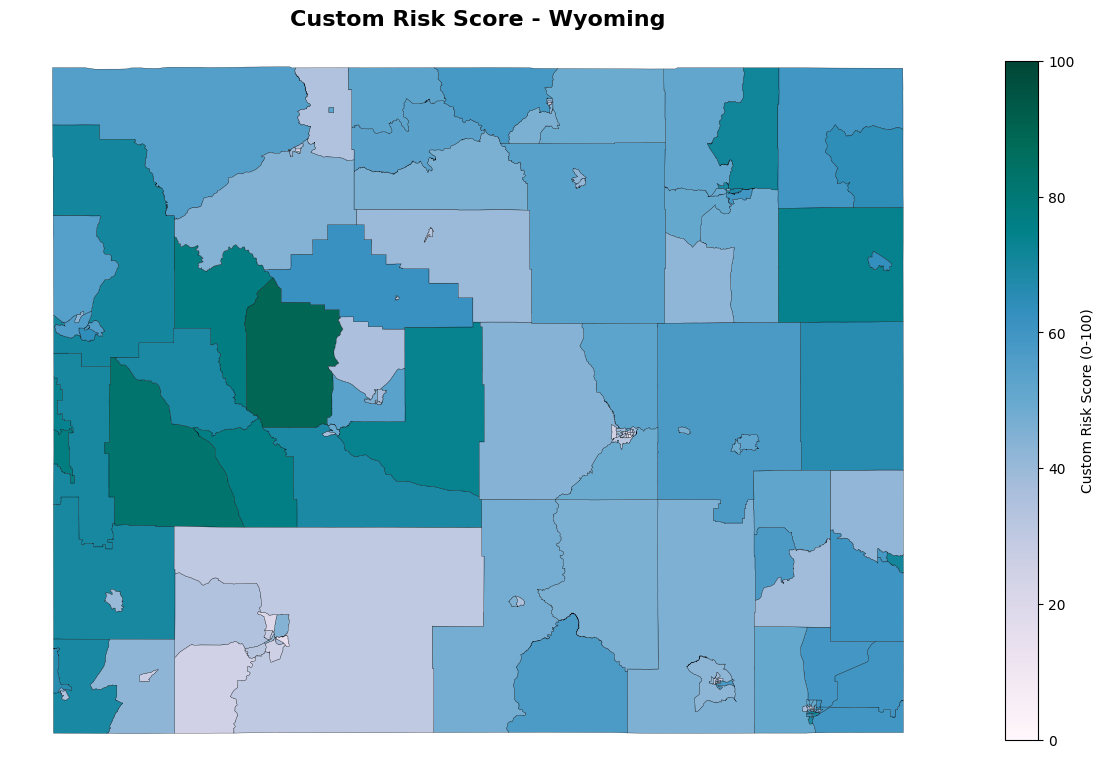

In [75]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

wyoming_map.plot(
    column="CUSTOM_RISK_SCORE",
    ax=ax,
    legend=True,
    linewidth=0.2,
    edgecolor="black",
    cmap="PuBuGn",
    vmin=0,
    vmax=100,
    legend_kwds={"label": "Custom Risk Score (0-100)", "shrink": 0.7},
    missing_kwds={"color": "lightgrey", "label": "No Data"}
)

ax.set_title("Custom Risk Score - Wyoming", fontsize=16, fontweight="bold")
ax.set_axis_off()

plt.tight_layout()
plt.show()

### Montana Custom Risk Map

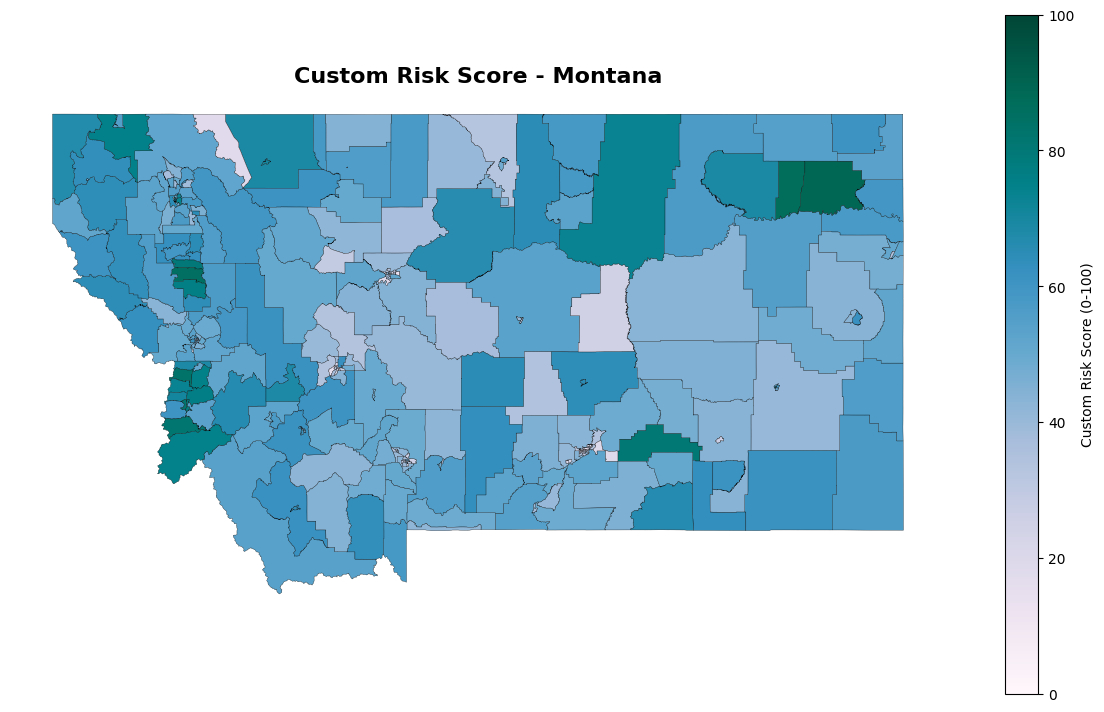

In [76]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

montana_map.plot(
    column="CUSTOM_RISK_SCORE",
    ax=ax,
    legend=True,
    linewidth=0.2,
    edgecolor="black",
    cmap="PuBuGn",
    vmin=0,
    vmax=100,
    legend_kwds={"label": "Custom Risk Score (0-100)", "shrink": 0.7},
    missing_kwds={"color": "lightgrey", "label": "No Data"}
)

ax.set_title("Custom Risk Score - Montana", fontsize=16, fontweight="bold")
ax.set_axis_off()

plt.tight_layout()
plt.show()

### Create Custom Risk Score

In [81]:
combined_data["CUSTOM_RISK_SCORE"] = (
    0.50 * combined_data["EAL_SCORE"] +
    0.35 * combined_data["SOVI_SCORE"] +
    0.15 * (100 - combined_data["RESL_SCORE"])
)

### Compare Risk Scores

In [79]:
state_summary = combined_data.groupby("STATE_NAME")[["RISK_SCORE", "CUSTOM_RISK_SCORE"]].mean()
state_summary

,RISK_SCORE,CUSTOM_RISK_SCORE
STATE_NAME,,
Montana,48.083104,47.164609
Wyoming,43.975430,47.118405


### Wildfire Risk Bar Graph

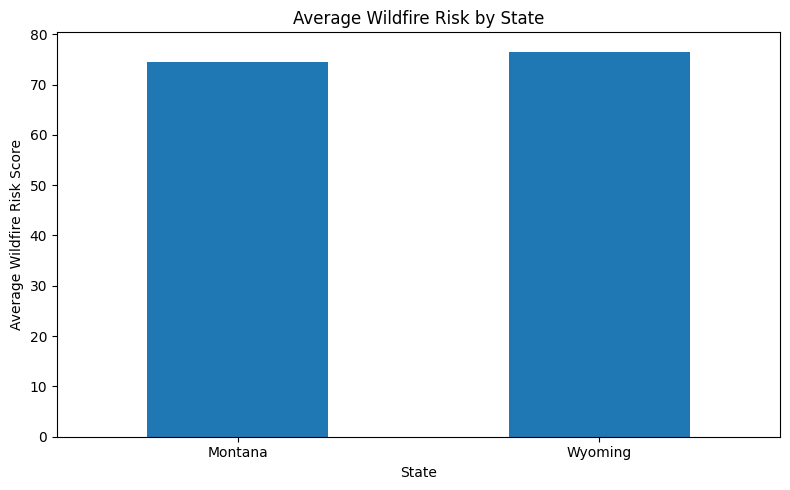

In [83]:
wildfire_summary = combined_data.groupby("STATE_NAME")["WFIR_RISKS"].mean()

wildfire_summary.plot(kind="bar", figsize=(8, 5))

plt.title("Average Wildfire Risk by State")
plt.xlabel("State")
plt.ylabel("Average Wildfire Risk Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()